H is different


H is the same
Transmon anharmonicity: -0.28 GHz
Transmon $\omega_{01}$: 3.3409903381196786 GHz
H is different
Fluxonium anharmonicity: 3.24 GHz
Fluxonium $\omega_{01}$: 0.4452510793213489 GHz


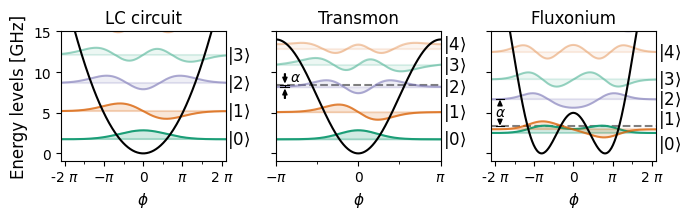

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh_tridiagonal
from scipy.special import eval_hermite
from math import factorial

# Parameters
phi_max = 10 * np.pi  # phase basis cutoff
N = 1000  # number of grid points
phi = np.linspace(-phi_max, phi_max, N)
dphi = phi[1] - phi[0]

def get_n2(N,max, periodic=False):
    arr_fund = [1/(dphi**2),-2/(dphi**2),1/(dphi**2)]
    arr = np.zeros((N,N))
    for i in range(N):
        for j in range(i-2,N):
            if i == j:
                arr[i][j] = arr_fund[1]
            elif i-j == 1 or i-j == -1:
                arr[i][j] = arr_fund[0]
            if j > i+1:
                break
    if periodic:
        arr[0][-1] = arr_fund[2]
        arr[-1][0] = arr_fund[2]
    return arr


energies = {
    "LC circuit": {
        "EL": 1.0,  # inductive energy (in units of charging energy)
        "EC": 1.5,  # charging energy (in units of charging energy)
    },
    "Transmon": {
        "EJ": 7.0,  # Josephson energy (in units of charging energy)
        "EC": 23.0,  # charging energy (in units of charging energy)
    },
    "Fluxonium": {
        "EJ": 4.5,  # Josephson energy (in units of charging energy)
        "EL": 1.0,  # inductive energy (in units of charging energy)
        "EC": 1.0,  # charging energy (in units of charging energy)
    },
    #"Fluxonium": {#MIT fluxonium
    #    "EJ": 5.71,
    #    "EL": 0.59,
    #    "EC": 1.3
    #}
    #"Fluxonium": {#Delft fluxonium
    #    "EJ": 4.92,
    #    "EL": 0.5,
    #    "EC": 0.88
    #}
}

# Kinetic energy

Ec = energies["Transmon"]["EC"]
T_trans = -4*Ec*get_n2(N, np.pi, periodic=True)
phi_trans = np.linspace(-np.pi, np.pi, N)
Ec = energies["LC circuit"]["EC"]
T_LC = -4*Ec*get_n2(N, phi_max, periodic=False)
Ec = energies["Fluxonium"]["EC"]
T_flux = -4*Ec*get_n2(N, phi_max, periodic=False)

# LC circuit — simple harmonic oscillator
V_LC = np.diag(0.5 * phi**2)

# Transmon — cosine potential
EJ = energies["Transmon"]["EJ"]
V_Transmon = np.diag(-EJ * np.cos(phi_trans))

# Fluxonium — cosine + parabolic offset (with external flux phi_ext=0)
EL = energies["Fluxonium"]["EL"]
EJ = energies["Fluxonium"]["EJ"]
V_Fluxonium = np.diag(-EJ * np.cos(phi-np.pi) + 0.5 * EL * phi**2)

# Function to diagonalize and plot eigenfunctions
smallest_y = 0.1
tallest_y = 1.0
colors = [
    '#1b9e77',
    '#d95f02',
    '#7570b3'
]
import pickle
import os
def eigs(V,T,name):
    H = V + T  # Hamiltonian
    if not os.path.exists(name+ "_H.pickle"):
        with open(name+ "_H.pickle", 'wb') as f:
            pickle.dump(np.zeros((N,N)), f)
    with open(name+ "_H.pickle", 'rb') as f:
        H_old = pickle.load(f)
        if H.shape == H_old.shape and np.allclose(H, H_old):
            print("H is the same")
            with open(name+ "_eigs.pickle", 'rb') as f:
                evals, evecs = pickle.load(f)
        else:
            print("H is different")
            evals, evecs = np.linalg.eigh(H)
            with open(name+ "_H.pickle", 'wb') as f:
                pickle.dump(H, f)
            with open(name+ "_eigs.pickle", 'wb') as f:
                pickle.dump((evals, evecs), f)
    return evals, evecs
    
from matplotlib.patches import FancyArrowPatch
from matplotlib import ticker
def annotate_vertical_dimension(ax, x, y1, y2, label, color='black', 
                                 text_offset=0.05, linewidth=0.8, tick_size=0.3):
    # Ensure y1 is lower than y2
    y_lower, y_upper = sorted([y1, y2])

    

    # Horizontal ticks
    ax.plot([x - tick_size-0.05, x + tick_size], [y_lower, y_lower], color=color, linewidth=linewidth)
    ax.plot([x - tick_size-0.05, x + tick_size], [y_upper, y_upper], color=color, linewidth=linewidth)


    # Rotated label at the center
    avg = (y_lower + y_upper) / 2
    if np.abs(y1-y2) > 1:
        ax.text(x+0.05, avg+0.05, r'{}'.format(label),
                color=color, va='center', ha='center', rotation=0, fontsize=10)
        # Vertical line
        #ax.plot([x, x], [y_lower, avg-0.5], color=color, linewidth=linewidth)
        #ax.plot([x, x], [avg+0.5, y_upper], color=color, linewidth=linewidth)
        #add arrow in between
        """ax.annotate('', xy=(x, y_upper+0.25), xytext=(x, avg+0.5),
                    arrowprops=ArrowStyle('Fancy',head_length=0.5, tail_width=linewidth),
                    va='center', ha='center', fontsize=12)"""
        ax.add_patch(FancyArrowPatch((x, avg+0.5), (x, y_upper+0.15),
                    arrowstyle=f'Simple,tail_width={linewidth*0.75},head_width=3,head_length=3.5',color=color))

        """ax.annotate('', xy=(x, y_lower-0.25), xytext=(x, avg-0.5),
                    arrowprops=dict(arrowstyle='-|>', color=color, lw=linewidth),
                    va='center', ha='center', fontsize=12)"""
        ax.add_patch(FancyArrowPatch((x, avg-0.5), (x, y_lower-0.15),
                    arrowstyle=f'Simple,tail_width={linewidth*0.75},head_width=3,head_length=3.5',color=color))
        
    else:
        ax.text(x+0.2, y_upper+0.1, r'{}'.format(label),
                color=color, va='bottom', ha='left', rotation=0,fontsize=10)
        # Vertical line
        ax.plot([x-0.01, x-0.01], [y_lower, y_upper], color=color, linewidth=linewidth)
        # add arrows pointing inwards
        ax.add_patch(FancyArrowPatch((x, y_upper+1.7), (x, y_upper),
                    arrowstyle=f'Simple,tail_width={linewidth*0.75},head_width=3,head_length=3.5',color=color))
        ax.add_patch(FancyArrowPatch((x, y_lower-1.7), (x, y_lower),
                    arrowstyle=f'Simple,tail_width={linewidth*0.75},head_width=3,head_length=3.5',color=color))

def plot_eigenfunctions(phi, V, T, title, ax, n_levels=6):
    global smallest_y, tallest_y, colors    
    H = V + T  # Hamiltonian
    #evals, evecs = np.linalg.eigh(H)  # Eigenvalues and eigenvectors
    if "Transmon" in title:
        ext = np.pi
    else:
        ext = 2.1*np.pi
    evals, evecs = eigs(V,T,title)
    # Normalize eigenvectors
    for i in range(len(evecs[0,:])):
        evecs[:,i] /= np.sqrt(np.sum(evecs[:,i]**2)*dphi)
        if "Transmon" in title:
            evecs[:,i] *=2
    #make the unidirectional
    for i in range(len(evecs[:,])):
        for j in range(len(evecs[0,:])):
            if not np.isclose(evecs[j,i], 0):
                evecs[:,i] /= np.sign(evecs[j,i])
                break

    V_min = np.min(V)
    evals -= V_min  # Shift eigenvalues to start from zero
    V = V - V_min  # Shift potential to start from zero


    B = evecs
    #V = B @ V @ B.T
    #H = B @ H @ B.T
    

    for n in range(n_levels):
        ax.plot(phi, evecs[:, n]*2 + evals[n], label=f'n={n}', color=colors[n%3], alpha=np.exp(-n*3e-1))
        ax.fill_between(phi, evals[n], evals[n] + evecs[:, n]*2, color=colors[n%3], alpha=0.2*np.exp(-n*3e-1))
        ax.plot(phi, [evals[n]]*len(phi), color=colors[n%3], alpha=0.2*np.exp(-n*3e-1))
        va = "center"
        ofs = 0.0
        if "Fluxonium" in title:
            if n == 0:
                va = "top"
                ofs = 0.05
            elif n == 1:
                va = "bottom"
                ofs = -0.05
        ax.annotate(
            rf'$|{n}\rangle$', xy=(0, evals[n]), xytext=(4.10*ext/np.pi, evals[n]+ofs+(evecs[:, n]*2)[-1]),    
            fontsize=12, color="k", ha='right', va=va)
    ax.plot(phi, np.diag(V), 'k', label='Potential')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(r'$\phi$', fontsize=11)

    #anharmonicity
    if "LC" not in title:
        ax.plot(phi, [evals[0]+2*(evals[1]-evals[0])]*len(phi), 'k--', alpha=0.5, zorder=-20)
        ts = 0.3
        x_shift = 0.0
        if "Transmon" in title:
            ts /= 2.0
        if "Fluxonium" in title:
            x_shift = 00
        annotate_vertical_dimension(ax, -2.8*ext/np.pi+x_shift, evals[2], evals[0]+2*(evals[1]-evals[0]), r'$\alpha$', color='k', text_offset=0.1, tick_size=ts)
        print(f'{title} anharmonicity: {(evals[2]-evals[1])-(evals[1]-evals[0]):.2f} GHz')
        print(rf'{title} $\omega_{{01}}$: {(evals[1]-evals[0])} GHz')
    
    #ax.grid(True)
    #ax.set_xlim(-phi_max/2, phi_max/2)
    if evals[0] < smallest_y:
        smallest_y = evals[0]
    if evals[n_levels-1] > tallest_y:
        tallest_y = evals[n_levels-1]
    ax.set_xlim(-ext, ext)
    if "LC" in title:
        ax.set_ylabel('Energy levels [GHz]',fontsize=12)

    #set tick font size
    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_fontsize(10)
        tick.label2.set_fontsize(10)
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_fontsize(10)
        tick.label2.set_fontsize(10)
    
    #set x-axis ticks in units of pi
    span = [-ext, ext]
    loc = ticker.MultipleLocator(np.pi)
    ax.xaxis.set_major_locator(loc)
    def func_format(x,_):
        string = f'{x/np.pi:.0f} $\pi$' if x != 0 else '0'
        if x/np.pi == 1:
            string = r'$\pi$'
        elif x/np.pi == -1:
            string = r'$-\pi$'
        return string
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(func_format))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(np.pi/2))


# Plotting
fig, axes = plt.subplots(1, 3, figsize=(7, 2.3), sharey=True, sharex=False)

plot_eigenfunctions(phi, V_LC, T_LC, 'LC circuit', axes[0])
plot_eigenfunctions(phi_trans, V_Transmon, T_trans, 'Transmon', axes[1])
plot_eigenfunctions(phi, V_Fluxonium, T_flux, 'Fluxonium', axes[2])
plt.ylim(smallest_y-1, 15)
fig.tight_layout()
plt.savefig('eigenfunctions.pdf')
plt.show()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Solving eigvals for 1,1,8,3.141592653589793,1.5707963267948966,50,50,10,__
Found cached eigvals, loading...
Solving eigvals for 1,1,8,3.141592653589793,1.5707963267948966,50,50,10,__
Found cached eigvals, loading...
Plotting n and phi


/home/ubuntu-compute/MassStorage/git/qdev_fastgates/bachelor/utils/qubit_init.py:100: SymPyDeprecationWarning: 

The expr_free_symbols property is deprecated. Use free_symbols to get
the free symbols of an expression.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-expr-free-symbols
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  for s in a.expr_free_symbols:
/home/ubuntu-compute/miniconda3/envs/qdev/lib/python3.11/site-packages/sympy/core/expr.py:2512: SymPyDeprecationWarning: 

The expr_free_symbols property is deprecated. Use free_symbols to get
the free symbols of an expression.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-expr-free-symbols
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  return {j for i in self.args for j in i.expr_free_symbols}
/home/ubuntu-compute/MassStorag

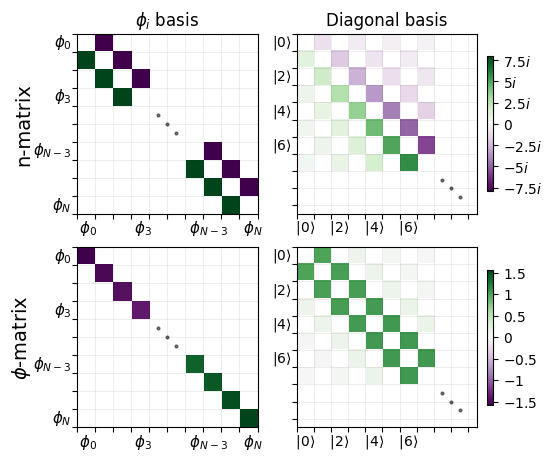

(array([[  0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ],
        [  0.        ,  10.2694688 ,   0.        ,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,  29.31114071,   0.        ,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        ,  55.95379074,
           0.        ,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        ,   0.        ,
          90.08063075,   0.        ,   0.        ,   0.        ,
           0.        ,   0.        ],
        [  0.        ,   0.        ,   0.        ,   0.        ,
           0.        , 131.54517771,   0.        ,   0.        ,
           0.        ,   0.   

In [67]:
#make a plot for the matrix elements
%load_ext autoreload
%autoreload
from utils.qubit_init import init_qubit
import numpy as np
init_qubit(1,1,8,np.pi,None,None,[],None,forceplot=True,truncation=10,base_ex=0.5*np.pi,base_size=50,force_size=True)

In [31]:
from qiskit.visualization import plot_bloch_vector
fig = plot_bloch_vector([1, 0, 0], title="Bloch Sphere")
fig.savefig('bloch_sphere.pdf')
plt.show()


Optimizing qubitoptimm_None,1,None,3.141592653589793,1,1,18.84955592153876,2000,50
Found cached optimization, loading...
Loaded
Optimized: [0.45008249 1.48827642]
Solving eigvals for 0.45008248984813537,1,1.4882764168083669,3.141592653589793,18.84955592153876,2000,50,2,__
Found cached eigvals, loading...
Solving eigvals for 0.45008248984813537,1,1.4882764168083669,3.141592653589793,18.84955592153876,2000,50,2,__
Found cached eigvals, loading...


/home/ubuntu-compute/MassStorage/git/qdev_fastgates/bachelor/utils/qubit_init.py:100: SymPyDeprecationWarning: 

The expr_free_symbols property is deprecated. Use free_symbols to get
the free symbols of an expression.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-expr-free-symbols
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  for s in a.expr_free_symbols:
/home/ubuntu-compute/miniconda3/envs/qdev/lib/python3.11/site-packages/sympy/core/expr.py:2512: SymPyDeprecationWarning: 

The expr_free_symbols property is deprecated. Use free_symbols to get
the free symbols of an expression.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-expr-free-symbols
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  return {j for i in self.args for j in i.expr_free_symbols}


Solving eigvals for 0.45008248984813537,1,1.4882764168083669,3.141592653589793,18.84955592153876,2000,50,2,__
Found cached eigvals, loading...
Solving eigvals for 0.45008248984813537,1,1.4882764168083669,3.141592653589793,18.84955592153876,2000,50,2,__
Found cached eigvals, loading...
Testing at t0 = 0.0
[1.+0.j 0.+0.j]
Testing at t0 = 0.3141483350441681
[1.+0.j 0.+0.j]
Testing at t0 = 0.6282966700883362
[1.+0.j 0.+0.j]
Testing at t0 = 0.9424450051325044
[1.+0.j 0.+0.j]
Testing at t0 = 1.2565933401766725
[1.+0.j 0.+0.j]
Testing at t0 = 1.5707416752208405
[1.+0.j 0.+0.j]
Testing at t0 = 1.8848900102650088
[1.+0.j 0.+0.j]
Testing at t0 = 2.1990383453091766
[1.+0.j 0.+0.j]
Testing at t0 = 2.513186680353345
[1.+0.j 0.+0.j]
Testing at t0 = 2.827335015397513
[1.+0.j 0.+0.j]


/home/ubuntu-compute/miniconda3/envs/qdev/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ubuntu-compute/miniconda3/envs/qdev/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/ubuntu-compute/miniconda3/envs/qdev/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ubuntu-compute/miniconda3/envs/qdev/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/ubuntu-compute/miniconda3/envs/qdev/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(v

Score for qubit_None_1_None_3.141592653589793_1.0016017865009355_inf_inf with RWA_x: (0.9842070697524289-8.095376221225099e-18j)
Score for qubit_None_1_None_3.141592653589793_1.0016017865009355_inf_inf with RWA_x: (0.9869245691340707-1.3877787807814457e-17j)
Score for qubit_None_1_None_3.141592653589793_1.0016017865009355_inf_inf with RWA_x: (0.9927652846461027-2.3129646346357427e-18j)
Score for qubit_None_1_None_3.141592653589793_1.0016017865009355_inf_inf with RWA_x: (0.9976542143834781-1.4166908387143924e-17j)
Score for qubit_None_1_None_3.141592653589793_1.0016017865009355_inf_inf with RWA_x: (0.9996760637505299-1.5901631863120731e-18j)
Score for qubit_None_1_None_3.141592653589793_1.0016017865009355_inf_inf with RWA_x: (0.9999817393060139+5.059610138265687e-19j)
Score for qubit_None_1_None_3.141592653589793_1.0016017865009355_inf_inf with RWA_x: (0.9996503749363981+1.8431436932253575e-17j)
Score for qubit_None_1_None_3.141592653589793_1.0016017865009355_inf_inf with RWA_x: (0.9975

<Figure size 500x500 with 0 Axes>

/tmp/ipykernel_37565/3208152335.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0,w_pad=0,h_pad=0)


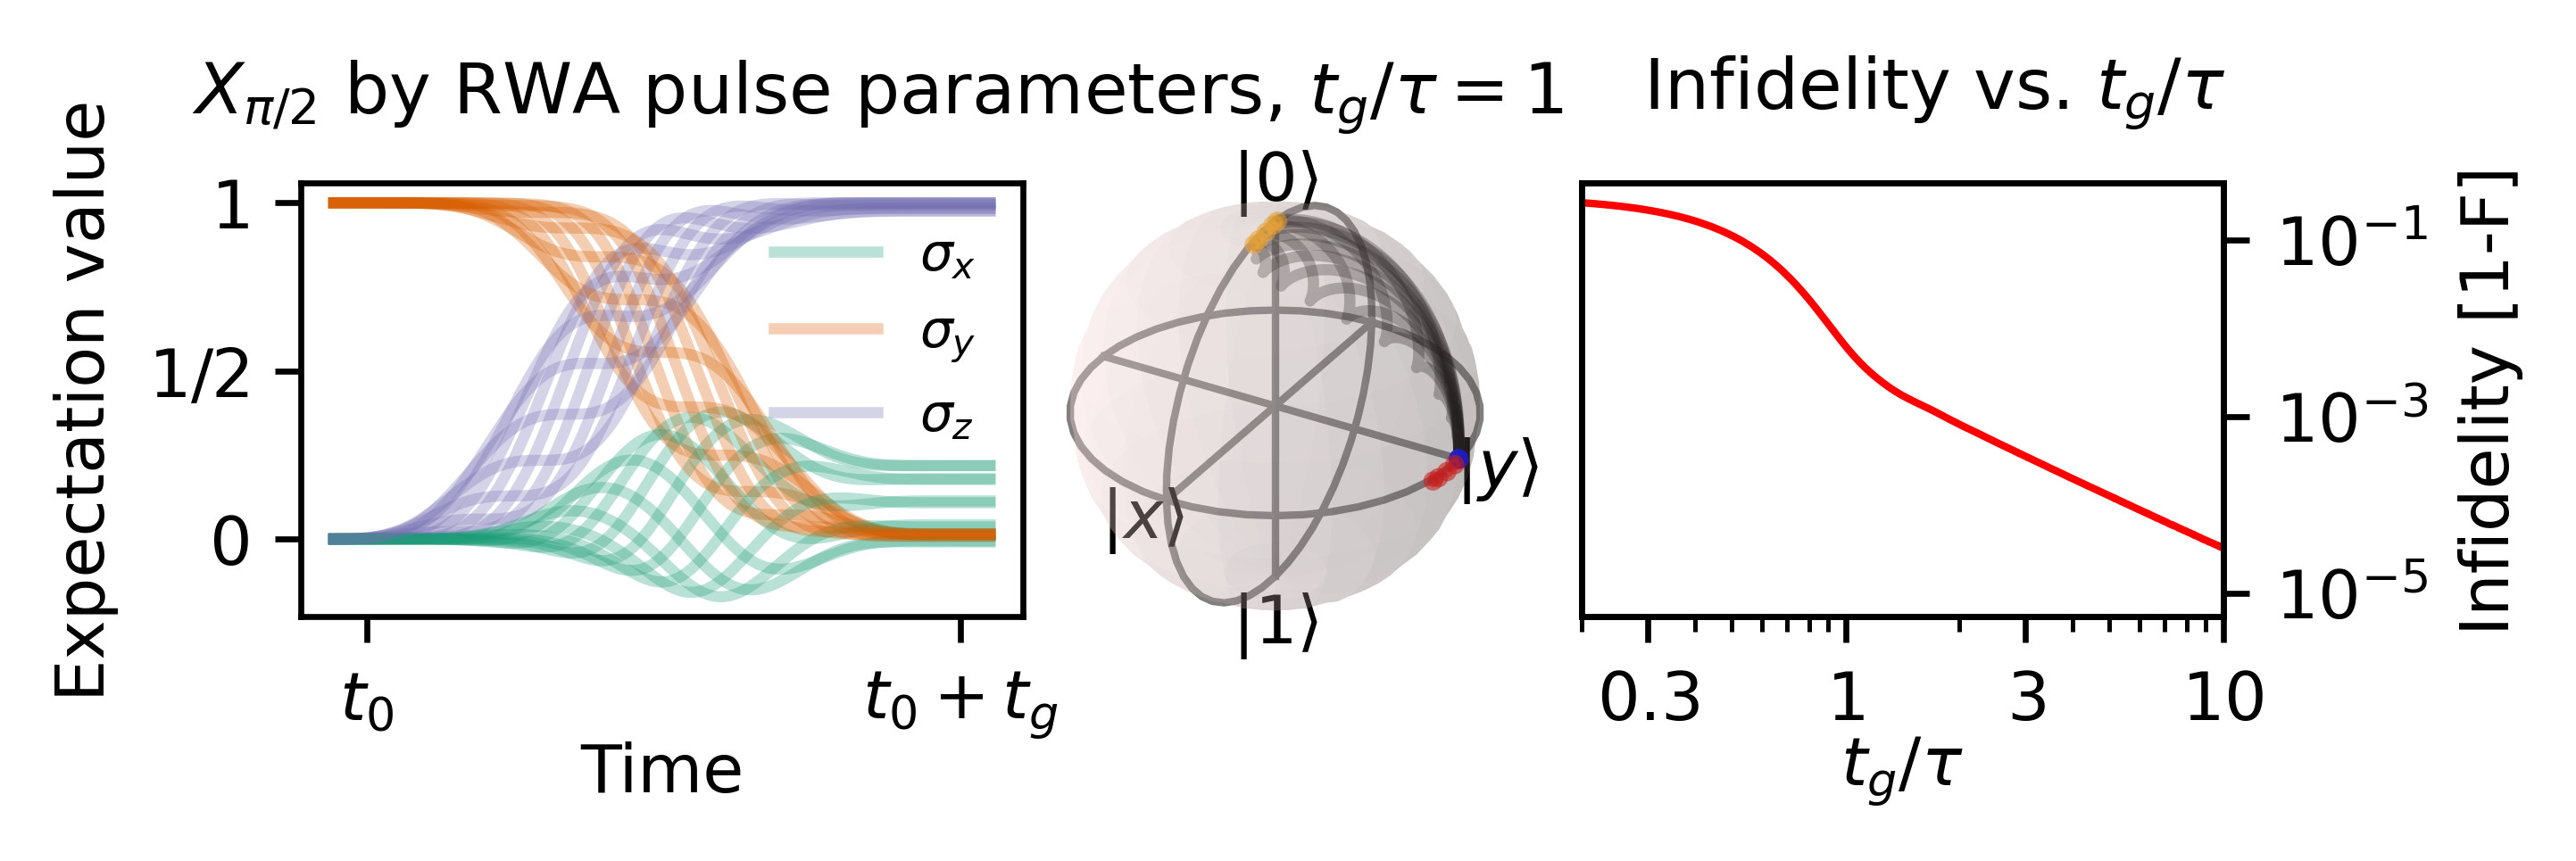

In [1]:
%load_ext autoreload
%autoreload

import os
import pickle
if "config.txt" in os.listdir(): 
    os.remove("config.txt")
with open("config.txt", "a") as f:
    f.write(f"bloch: True\n")

#with open("../scores_withmeta_onlyRWA_noDecay.pickle", "rb") as f:
with open("../scores_withmeta.pickle", "rb") as f:
    scores = pickle.load(f)
    scores = scores["RWA_x_nooptim"]
    Lambdas = []
    fidelity = []
    for i in range(len(scores)):
        Lambdas.append(scores[i]["Lambdas"])
        fidelity.append(scores[i]["score"])

#plot the population transfer on a bloch sphere
from utils.eval_functions import do_test, AdaptiveLearner, calib_gate
from utils.gate_params import get_gate_params
import utils.gate_evaluator
import numpy as np
from matplotlib import pyplot as plt
gate_names_2_eval = [#actual values are hidden off in the other file
    #"commensurate_x_virt_z_nooptim",
    "FAST-MAGNUS_nooptim",
    #"commensurate_x_virt_z",
    "FAST-DRAG_nooptim",
    "RWA_x_nooptim",
    #"corotating_xy_virt_z",
    "magnus1_x_virt_z_nooptim",
    "corotating_xy_virt_z_nooptim",
    #"magnus1_x_virt_z",
]
gate = get_gate_params(gate_names_2_eval[2])
learner = AdaptiveLearner([], [None, 1, None, 1, 1, np.pi, (1.0,1.01), np.inf, np.inf], framework="random",truncation=2)
qubits_2_eval = learner.get_next_dp(N=1)
for i in range(len(qubits_2_eval)):
    qubits_2_eval[i]["Ec_IC"] = 1
    qubits_2_eval[i]["El_IC"] = 1
    qubits_2_eval[i]["Ej_IC"] = 1
qubits_2_eval[0], gate = calib_gate((qubits_2_eval[0], gate))

s,_=do_test(qubits_2_eval[0],gate)

ax = utils.gate_evaluator.axs[2]
sort = np.argsort(Lambdas)
Lambdas = np.array(Lambdas)[sort]
fidelity = np.array(fidelity)[sort]
#put a star denoting where the l.h.s. plot is on the right axis
lmbda = 1.0
fid = 1-s[0]
#ax.plot([lmbda], [fid], marker='*', markersize=5, color='black', label='LHS plot point', zorder=10)
ax.plot(Lambdas, 1-np.array(fidelity), color='red', label='Fidelity', linewidth=1)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'$t_g/\tau$', fontsize=9, labelpad=0)
axt = ax.twinx()
axt.set_yscale('log')
axt.set_ylim(ax.get_ylim())
ax.set_yticks([])
ax.set_yticklabels([])
axt.set_ylabel('Infidelity [1-F]', fontsize=9)
ax.set_xlim(0.2,10)
axt.set_yticks([1e-6,1e-4, 1e-2, 1])
axt.set_yticklabels([r'$10^{-6}$', r'$10^{-4}$',r'$10^{-2}$', '1'], fontsize=9)
#x tick size
ax.set_xticks([0.3, 1, 3, 10])
ax.set_xticklabels([r'$0.3$', r'$1$', r'$3$', r'$10$'], fontsize=9)
#get the minor ticks from the left yaxis and put them on the right
minor_ticks = ax.get_yticks(minor=True)
axt.set_yticks(minor_ticks, minor=True)
#axt.set_yticks([1e-6,1e-5,1e-4,1e-3, 1e-2, 1e-1, 1])
#axt.set_yticklabels([r'$10^{-6}$',r'$10^{-5}$',r'$10^{-4}$', r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', '1'], fontsize=9)
axt.set_yticks([1e-5,1e-3, 1e-1])
axt.set_yticklabels([r'$10^{-5}$',r'$10^{-3}$', r'$10^{-1}$'], fontsize=9)
axt.set_ylim(ax.get_ylim())
ax.set_yticks([], minor=True)

#get the markers on ax1 and reformat them
ax1 = utils.gate_evaluator.axs[1]
print(ax1.collections)
print(ax1.lines)
b = utils.gate_evaluator.bloch
print(b.point_alpha)
types = b.point_style
for i in range(len(b.point_size)):
    if i == 3:
        b.point_size[i] = 1
        b.point_marker[i] = ' '
    b.point_size[i] = 10
    b.point_marker[i] = '.'
for i in range(len(b.point_alpha)):
    if types[i] != 'l':
        b.point_alpha[i] = 0.2
    #b.point_color[i] = 'black'
#b.point_default_color[-1] = b.point_default_color[-2]
b.show()

#plt.tight_layout()
plt.tight_layout(pad=0,w_pad=0,h_pad=0)
plt.savefig("bloch_sphere.pdf", bbox_inches='tight')
plt.show()


/tmp/ipykernel_65837/3055179236.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


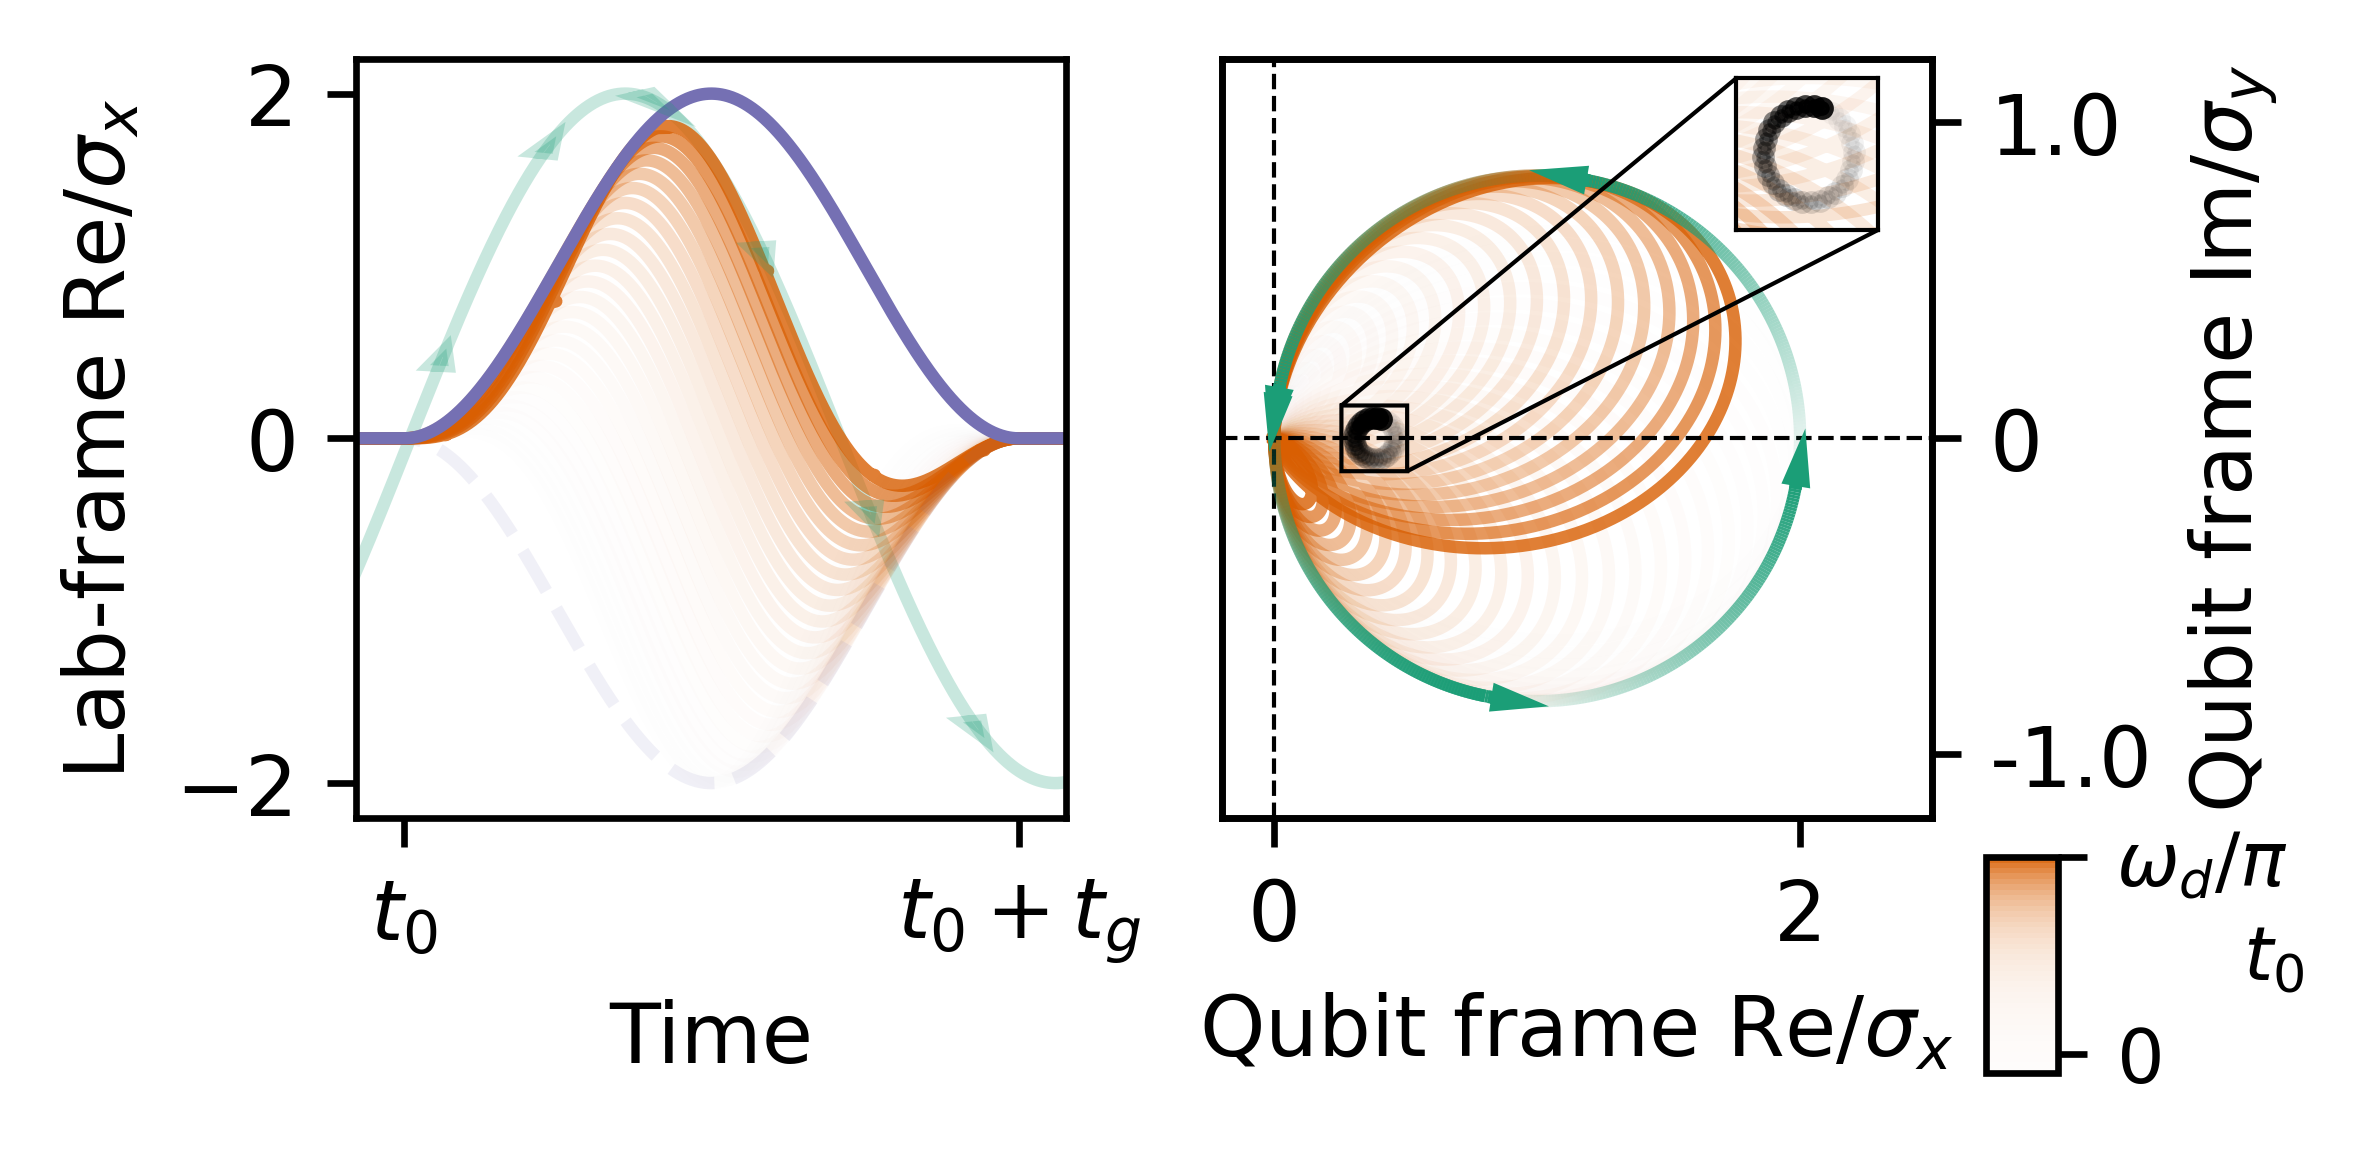

In [1]:
#create a phase-space illustration of the |1><0| matrix element under a drive envelope
import numpy as np
import matplotlib.pyplot as plt


#for omega_d in np.linspace(0.5, 2.5, 20)*np.pi:
omega_d = 1.1*np.pi
alpha = 0.8
alpha2 = 0.9
fig, ax = plt.subplots(1, 2, figsize=(4, 2),dpi=600)
dt_0 = 0.7
#zoomin
e = 0.25
a_x, a_y = 0.38, 0
x1,x2 = a_x-e/2, a_x+e/2
y1,y2 = a_y-e/2, a_y+e/2
axins = ax[1].inset_axes(
    [0.725, 0.775, 0.2, 0.2],
    xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[],xticks=[], yticks=[],
)
ax[1].indicate_inset_zoom(axins, edgecolor="black", lw=0.5, alpha=1, ls='-')
for k in axins.spines.keys():
    axins.spines[k].set_linewidth(0.5)

t_0s = np.linspace(0, omega_d/np.pi, 40)
clrs = []
for t_0 in t_0s:
    t_0 += dt_0
    #t_0 = 0.1
    cs = [
        '#1b9e77',
        '#d95f02',
        '#7570b3'
    ]
    t_g = 1.3
    #omega_d = 1.4*np.pi
    X = np.linspace(-0.2, t_g+0.2, 1000, dtype=np.float64)
    period = np.pi/ omega_d
    period_idx = np.argmin(np.abs(X+0.2 - period))
    global_shift = np.argmin(np.abs(X))
    #envelope = np.piecewise(X, [False, True], [lambda x: 1-np.cos(2*np.pi*(x-t_0)/t_g), 0])
    def envelope_func(t):
        if t < 0 or t >  t_g:
            return 0
        else:
            return float(1 - np.cos(2 * np.pi * (t) / t_g))
    envelope = np.array([envelope_func(t) for t in X], dtype=np.float64)
    element = 1+ np.exp(2j * (omega_d * X+omega_d * t_0+omega_d*t_g/2))
    element_0 = np.cos(omega_d * X+omega_d * t_0+omega_d*t_g/2)
    eelem = element * envelope/2
    eelem_0 = 2*(element_0) * envelope
    
    if np.isclose(t_0,dt_0):
        ax[0].plot(X, 2*element_0, label='Matrix Element', color=cs[0], alpha=0.3*alpha)
        #make arrows for bits of the envelope
        s = 100
        for shift in range(0, len(X), period_idx//4):
            if shift < period_idx//4:
                continue
            bit_X = X[shift-s:shift-s+2]
            bit_Y = (2*element_0)[shift-s:shift-s+2].astype(np.float64)
            l = np.linalg.norm([bit_X[1]-bit_X[0], bit_Y[1]-bit_Y[0]])
            bit_X[1] = bit_X[0] + 0.05 * ((bit_X[1]-bit_X[0]) / l)
            bit_Y[1] = bit_Y[0] + 0.05 * ((bit_Y[1]-bit_Y[0]) / l)
            ax[0].arrow(bit_X[0], bit_Y[0], bit_X[1]-bit_X[0], bit_Y[1]-bit_Y[0],
                        head_width=0.04, head_length=0.1, fc=cs[0], ec=cs[0], lw=1.5, zorder=10,alpha=0.3*alpha,
                        length_includes_head=True)
    #two subplot, one for the time-axis envelope, and one for phase space
    
    ax[0].set_xlabel('Time')
    ax[0].set_ylabel(rf'Lab-frame Re/$\sigma_x$')
    #ax[0].set_title('Real signal component vs. time')
    #ax[0].grid(True)
    
    ax[1].plot(np.real(eelem), np.imag(eelem), label='Matrix Element with Envelope', color=cs[1], alpha=alpha)
    ax[1].scatter(np.mean(np.real(eelem)), np.mean(np.imag(eelem)), color="black", s=3, label='Mean Element', alpha=alpha2, zorder=10)
    ax[0].plot(X, np.real(eelem_0/2), label='Matrix Element', color=cs[1], alpha=alpha)
    axins.plot(np.real(eelem), np.imag(eelem), label='Matrix Element with Envelope', color=cs[1], alpha=alpha)
    axins.scatter(np.mean(np.real(eelem)), np.mean(np.imag(eelem)), color="black", s=3, label='Mean Element', alpha=alpha2, zorder=10)
    hex2rgb = lambda h: tuple(int(h[i:i+2], 16) for i in (1, 3, 5))
    clr = hex2rgb(cs[1])
    rgba = (clr[0]/255, clr[1]/255, clr[2]/255, alpha2)
    clrs.append(rgba)
    alpha *= 0.8
    alpha2 *= 0.9
    
    

ax[0].plot(X, envelope, label='Drive Envelope', color=cs[2],alpha=1)
ax[0].plot(X, -envelope, label='Drive Envelope', color=cs[2],alpha=0.1, ls='--')


    
ax[1].set_xlabel('Qubit frame Re/$\sigma_x$')
#ax[1].set_ylabel(fr'Qubit frame Im/$\sigma_y$')
ax[1].set_yticks([])
ax[1].set_yticklabels([])
#ax[1].set_title(fr'$|1\rangle\langle0|$ element phase')
#ax[1].grid(True)
ax[1].set_aspect('equal', adjustable='box')
ax[1].set_xlim(-0.2, 2.5)
ax[1].set_ylim(-1.5, 1.5)
#ax[0].legend()
#ax[1].legend()
ax[1].axhline(0, color='black', lw=0.5, ls='--')
ax[1].axvline(0, color='black', lw=0.5, ls='--')
from matplotlib import patches
style = "C"
if style == "A":
    ax[1].plot(np.real(element), np.imag(element), label='Matrix Element', color=cs[0])
if style == "B":
    a1 = patches.FancyArrowPatch((1, 1), (2, 0),
                                connectionstyle="arc3,rad=-0.4",zorder=10,
                                arrowstyle='-|>', mutation_scale=15, color=cs[0], lw=1.5)
    a2 = patches.FancyArrowPatch((2, 0), (1, -1),
                                connectionstyle="arc3,rad=-0.4",zorder=10,
                                arrowstyle='-|>', mutation_scale=15, color=cs[0], lw=1.5)
    a3 = patches.FancyArrowPatch((1, -1), (0, 0),
                                connectionstyle="arc3,rad=-0.4",zorder=10,
                                arrowstyle='-|>', mutation_scale=15, color=cs[0], lw=1.5)
    a4 = patches.FancyArrowPatch((0, 0), (1, 1),
                                connectionstyle="arc3,rad=-0.4",zorder=10,
                                arrowstyle='-|>', mutation_scale=15, color=cs[0], lw=1.5)
    ax[1].add_patch(a3)
    ax[1].add_patch(a4)
    ax[1].add_patch(a1)
    ax[1].add_patch(a2)
if style == "C":
    """ax[1].plot(np.real(element), np.imag(element), label='Matrix Element', color=cs[0], alpha=0.5)
    ax[1].scatter(np.mean(np.real(element)), np.mean(np.imag(element)), color="black", s=6, label='Mean Element', alpha=alpha2, zorder=10)
    ax[1].plot([0, 1], [0, 1], color=cs[0], lw=0.5, ls='--', alpha=0.5)
    ax[1].plot([0, 2], [0, 0], color=cs[0], lw=0.5, ls='--', alpha=0.5)"""

    #h = input('Enter hex: ').lstrip('#')
    rgb = tuple(int(cs[0][i+1:i+3], 16) for i in (0, 2, 4))
    rgba_s = [
        (rgb[0]/255, rgb[1]/255, rgb[2]/255, x*4) for x in np.linspace(0, 1, len(element[:period_idx]))
    ]

    #cs_arr1 = 
    #ax[1].plot(np.real(element), np.imag(element), label='Matrix Element', color=rgba_s)
    #use lineconnection to plot the element with the specified colors
    # Create line segments for phase space trajectory
    from matplotlib.collections import LineCollection
    for shift in range(0, period_idx, period_idx//4):
        points = np.array([np.real(element[shift:shift+period_idx//4]), np.imag(element[shift:shift+period_idx//4])]).T
        segments = np.stack([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, colors=rgba_s[:-1], linewidths=1.5, label='Matrix Element')
        ax[1].add_collection(lc)
        endbit = segments[:1]
        #ax[1].plot(endbit[:, 0], endbit[:, 1], lw=1.5, color="red")
        #use endbit to plot an arrow
        """endbit -= 1
        endbit *= 1.1
        endbit += 1"""
        ax[1].arrow(endbit[0][0][0], endbit[0][0][1], endbit[0][1][0]-endbit[0][0][0], endbit[0][1][1]-endbit[0][0][1],
                    head_width=0.05, head_length=0.1, fc=cs[0],ec=cs[0], lw=1.5, zorder=10)
    

#set a star for reference
ax[0].set_xlim(-0.1,t_g+0.1)
#ax[0].scatter(0.56, 1.8, color="black", s=30, label='Reference', alpha=1, zorder=10, marker='*')
#ax[1].scatter(1.75, 0.4, color="black", s=30, label='Reference', alpha=1, zorder=10, marker='*')
#ax[0].scatter(1.04, -0.25, color="black", s=30, label='Reference', alpha=1, zorder=10, marker='*')
#ax[1].scatter(0.15, -0.25, color="black", s=30, label='Reference', alpha=1, zorder=10, marker='*')
ax[0].set_xticks([0, t_g])
ax[0].set_xticklabels([rf'$t_0$', rf'$t_0 + t_g$'])
axt = ax[1].twinx()
axt.set_ylabel(rf'Qubit frame Im/$\sigma_y$')
axt.set_ylim(-1.2, 1.2)
axt.set_yticks([-1.0,0,1.0])
axt.set_yticklabels(['-1.0', '0', '1.0'])

#use t_0s and clrs to construct a colormap and colorbar
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap
trunc = len(t_0s)//1
norm = Normalize(vmin=min(t_0s[:trunc]), vmax=max(t_0s[:trunc]))
cmap = LinearSegmentedColormap.from_list('my_cmap', clrs[:trunc], N=len(t_0s[:trunc]))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # only needed for older versions of matplotlib
cbarax = fig.add_axes([0.5, 0.08, 0.4, 0.18])  # [left, bottom, width, height]
cbarax.set_axis_off()  # Hide the colorbar axis
cbar = plt.colorbar(sm, ax=cbarax, orientation='vertical', pad=0.02, aspect=3)
# Set the colorbar label and shift it upward by adjusting the position
cbar.set_label(rf'$t_0$', fontsize=9, rotation=0, labelpad=0.0)
cbar.ax.yaxis.set_label_coords(4, 0.7)  # (x, y): x > 1 moves label up and right
cbar.ax.tick_params(labelsize=9)
cbar.set_ticks([0, 1.0])
cbar.set_ticklabels([r'$\omega_d/\pi$', r'$0$'])
cbar.ax.invert_yaxis()  # Invert the colorbar to match the plot

plt.tight_layout()

plt.savefig('phase_space_matrix_element.pdf')
plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Optimizing qubitoptimm_None,1,None,3.141592653589793,1,1.99,18.84955592153876,2000,50
Solving eigvals for 0.4,1,1.3,3.141592653589793,18.84955592153876,2000,50
Found cached eigvals, loading...
Solving eigvals for 0.42000000000000004,1,1.3,3.141592653589793,18.84955592153876,2000,50
Found cached eigvals, loading...


/home/ubuntu-compute/MassStorage/git/qdev_fastgates/bachelor/utils/qubit_init.py:100: SymPyDeprecationWarning: 

The expr_free_symbols property is deprecated. Use free_symbols to get
the free symbols of an expression.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-expr-free-symbols
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  for s in a.expr_free_symbols:
/home/ubuntu-compute/miniconda3/envs/qdev/lib/python3.11/site-packages/sympy/core/expr.py:2512: SymPyDeprecationWarning: 

The expr_free_symbols property is deprecated. Use free_symbols to get
the free symbols of an expression.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-expr-free-symbols
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  return {j for i in self.args for j in i.expr_free_symbols}


Solving eigvals for 0.4,1,1.3650000000000002,3.141592653589793,18.84955592153876,2000,50
Found cached eigvals, loading...
Solving eigvals for 0.42000000000000004,1,1.365,3.141592653589793,18.84955592153876,2000,50
Found cached eigvals, loading...
Solving eigvals for 0.42999999999999994,1,1.3975,3.141592653589793,18.84955592153876,2000,50
Found cached eigvals, loading...
Solving eigvals for 0.4099999999999999,1,1.4625000000000001,3.141592653589793,18.84955592153876,2000,50
Found cached eigvals, loading...
Solving eigvals for 0.4049999999999998,1,1.5437500000000006,3.141592653589793,18.84955592153876,2000,50
Found cached eigvals, loading...
Solving eigvals for 0.4349999999999997,1,1.5762500000000004,3.141592653589793,18.84955592153876,2000,50
Found cached eigvals, loading...
Solving eigvals for 0.45249999999999946,1,1.6818750000000007,3.141592653589793,18.84955592153876,2000,50
Found cached eigvals, loading...
Solving eigvals for 0.4274999999999993,1,1.8281250000000013,3.141592653589793,

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    22  100    22    0     0     78      0 --:--:-- --:--:-- --:--:--    78
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    22  100    22    0     0    161      0 --:--:-- --:--:-- --:--:--   161


Waiting 0.7921747352965733 seconds for GPU


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    22  100    22    0     0     80      0 --:--:-- --:--:-- --:--:--    81


Waiting 1.582530042218926 seconds for GPU
Array created on GPU 0


/home/ubuntu-compute/MassStorage/git/qdev_fastgates/bachelor/utils/qubit_init.py:100: SymPyDeprecationWarning: 

The expr_free_symbols property is deprecated. Use free_symbols to get
the free symbols of an expression.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-expr-free-symbols
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  for s in a.expr_free_symbols:
/home/ubuntu-compute/miniconda3/envs/qdev/lib/python3.11/site-packages/sympy/core/expr.py:2512: SymPyDeprecationWarning: 

The expr_free_symbols property is deprecated. Use free_symbols to get
the free symbols of an expression.

See https://docs.sympy.org/latest/explanation/active-deprecations.html#deprecated-expr-free-symbols
for details.

This has been deprecated since SymPy version 1.9. It
will be removed in a future version of SymPy.

  return {j for i in self.args for j in i.expr_free_symbols}
/home/ubuntu-compute/miniconda3

Solving eigvals for 1.0208875594916709,1,3.0004239725630097,3.141592653589793,20.420352248333657,3000,50,3,__
Found cached eigvals, loading...


/home/ubuntu-compute/MassStorage/git/qdev_fastgates/bachelor/utils/gate_params.py:104: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  scipy.integrate.quad(
/home/ubuntu-compute/miniconda3/envs/qdev/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ubuntu-compute/miniconda3/envs/qdev/lib/python3.11/site-packages/matplotlib/transforms.py:757: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)


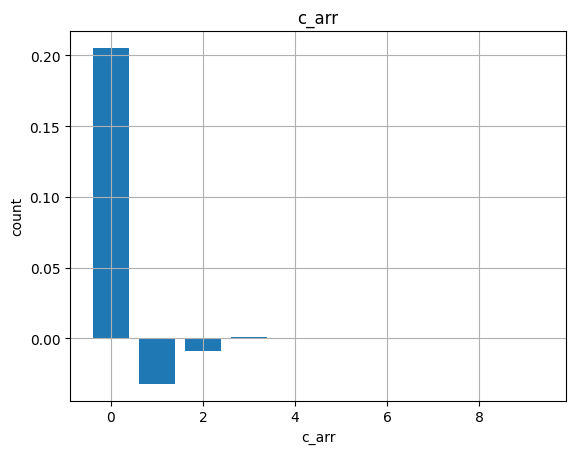

Testing at t0 = 0.0
[1.+0.j 0.+0.j]
Testing at t0 = 1.0572768331708435
[1.+0.j 0.+0.j]
Testing at t0 = 2.114553666341687
[1.+0.j 0.+0.j]
Score for qubit_None_1_None_3.141592653589793_1.5000843661545522_inf_inf with FAST_nooptim: (0.9995271165202255+6.216092455583558e-18j)
Score for qubit_None_1_None_3.141592653589793_1.5000843661545522_inf_inf with FAST_nooptim: (0.9996274408895661-4.1561083278611e-18j)
Score for qubit_None_1_None_3.141592653589793_1.5000843661545522_inf_inf with FAST_nooptim: (0.9996281594385952+1.0336060711028475e-17j)


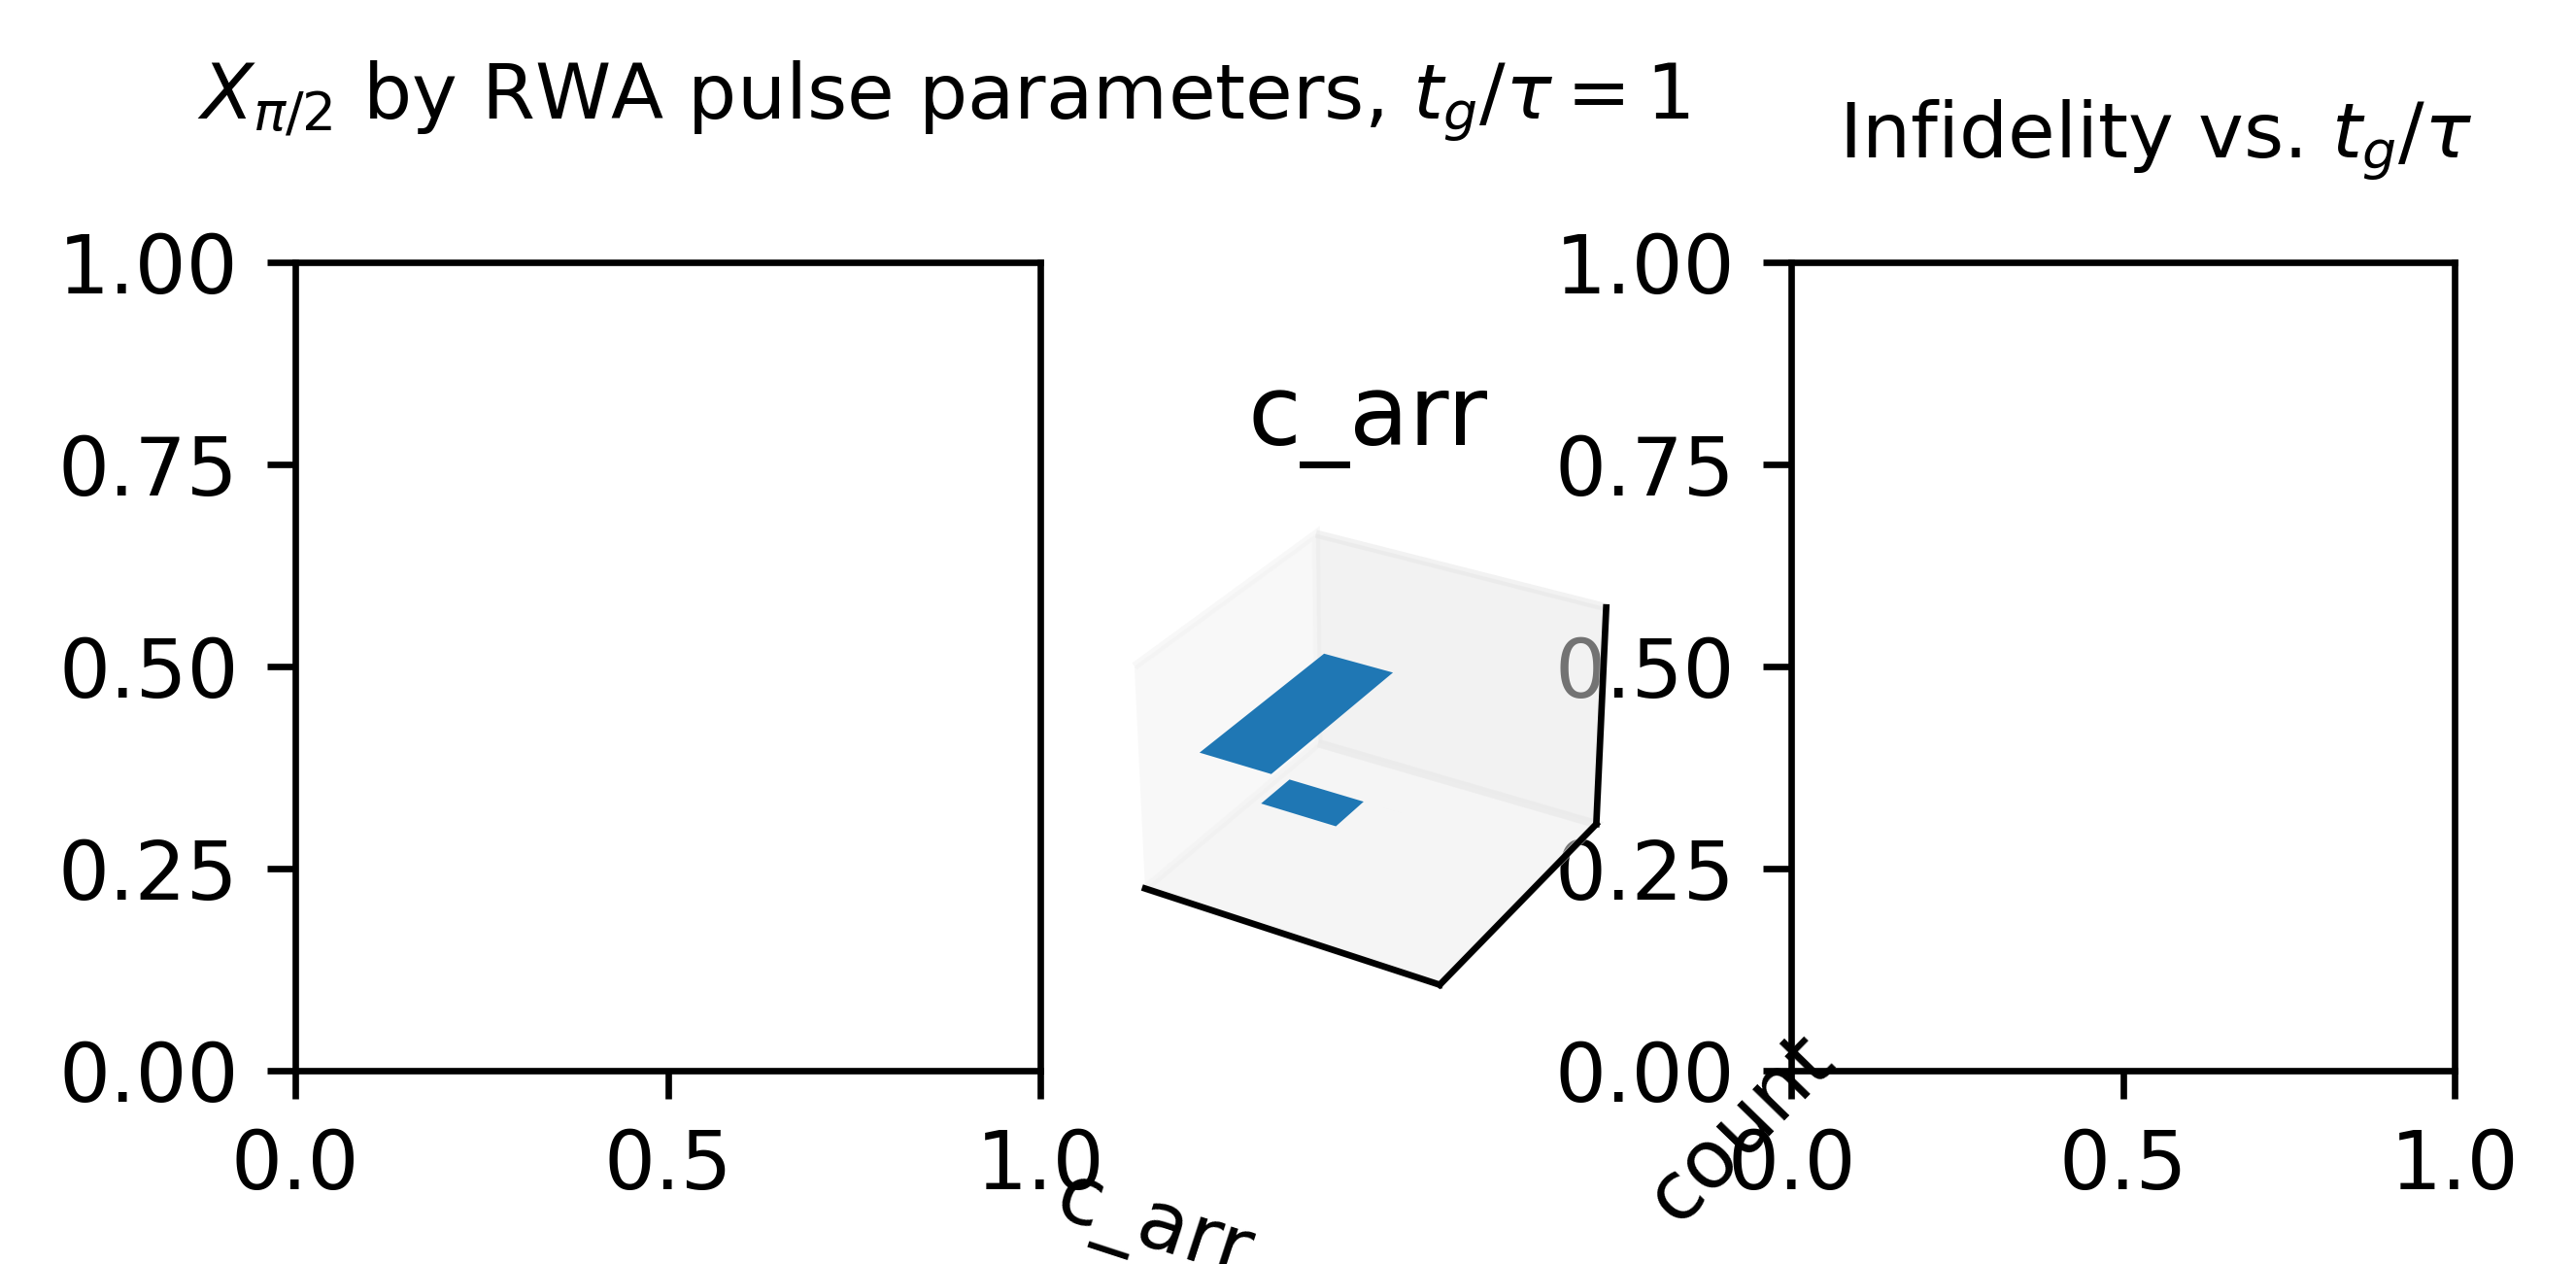

Testing at t0 = 0.0
[1.+0.j 0.+0.j]
Testing at t0 = 1.0572768331708435
[1.+0.j 0.+0.j]
Testing at t0 = 2.114553666341687
[1.+0.j 0.+0.j]
Score for qubit_None_1_None_3.141592653589793_1.5000843661545522_inf_inf with FAST-MAGNUS: (0.9993470711972493-6.64977332457776e-18j)
Score for qubit_None_1_None_3.141592653589793_1.5000843661545522_inf_inf with FAST-MAGNUS: (0.9995854101064962-3.998419027513925e-18j)
Score for qubit_None_1_None_3.141592653589793_1.5000843661545522_inf_inf with FAST-MAGNUS: (0.9995862928639543+1.235990476633475e-17j)


  0%|          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_2781/1011549080.py:42: ComplexWarning: Casting complex values to real discards the imaginary part
  envelope = np.array([envelope_func(t) for t in X], dtype=np.float64)
  0%|          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_2781/1011549080.py:47: ComplexWarning: Casting complex values to real discards the imaginary part
  envelope = np.array([envelope_func2(t) for t in X], dtype=np.float64)
100%|██████████| 1000/1000 [00:01<00:00, 701.84it/s]
/tmp/ipykernel_2781/1011549080.py:154: ComplexWarning: Casting complex values to real discards the imaginary part
  envelope = np.array([envelope_func(t) for t in X], dtype=np.float64)
/tmp/ipykernel_2781/1011549080.py:157: ComplexWarning: Casting complex values to real discards the imaginary part
  envelope2 = np.array([envelope_func2(t) for t in X], dtype=np.float64)


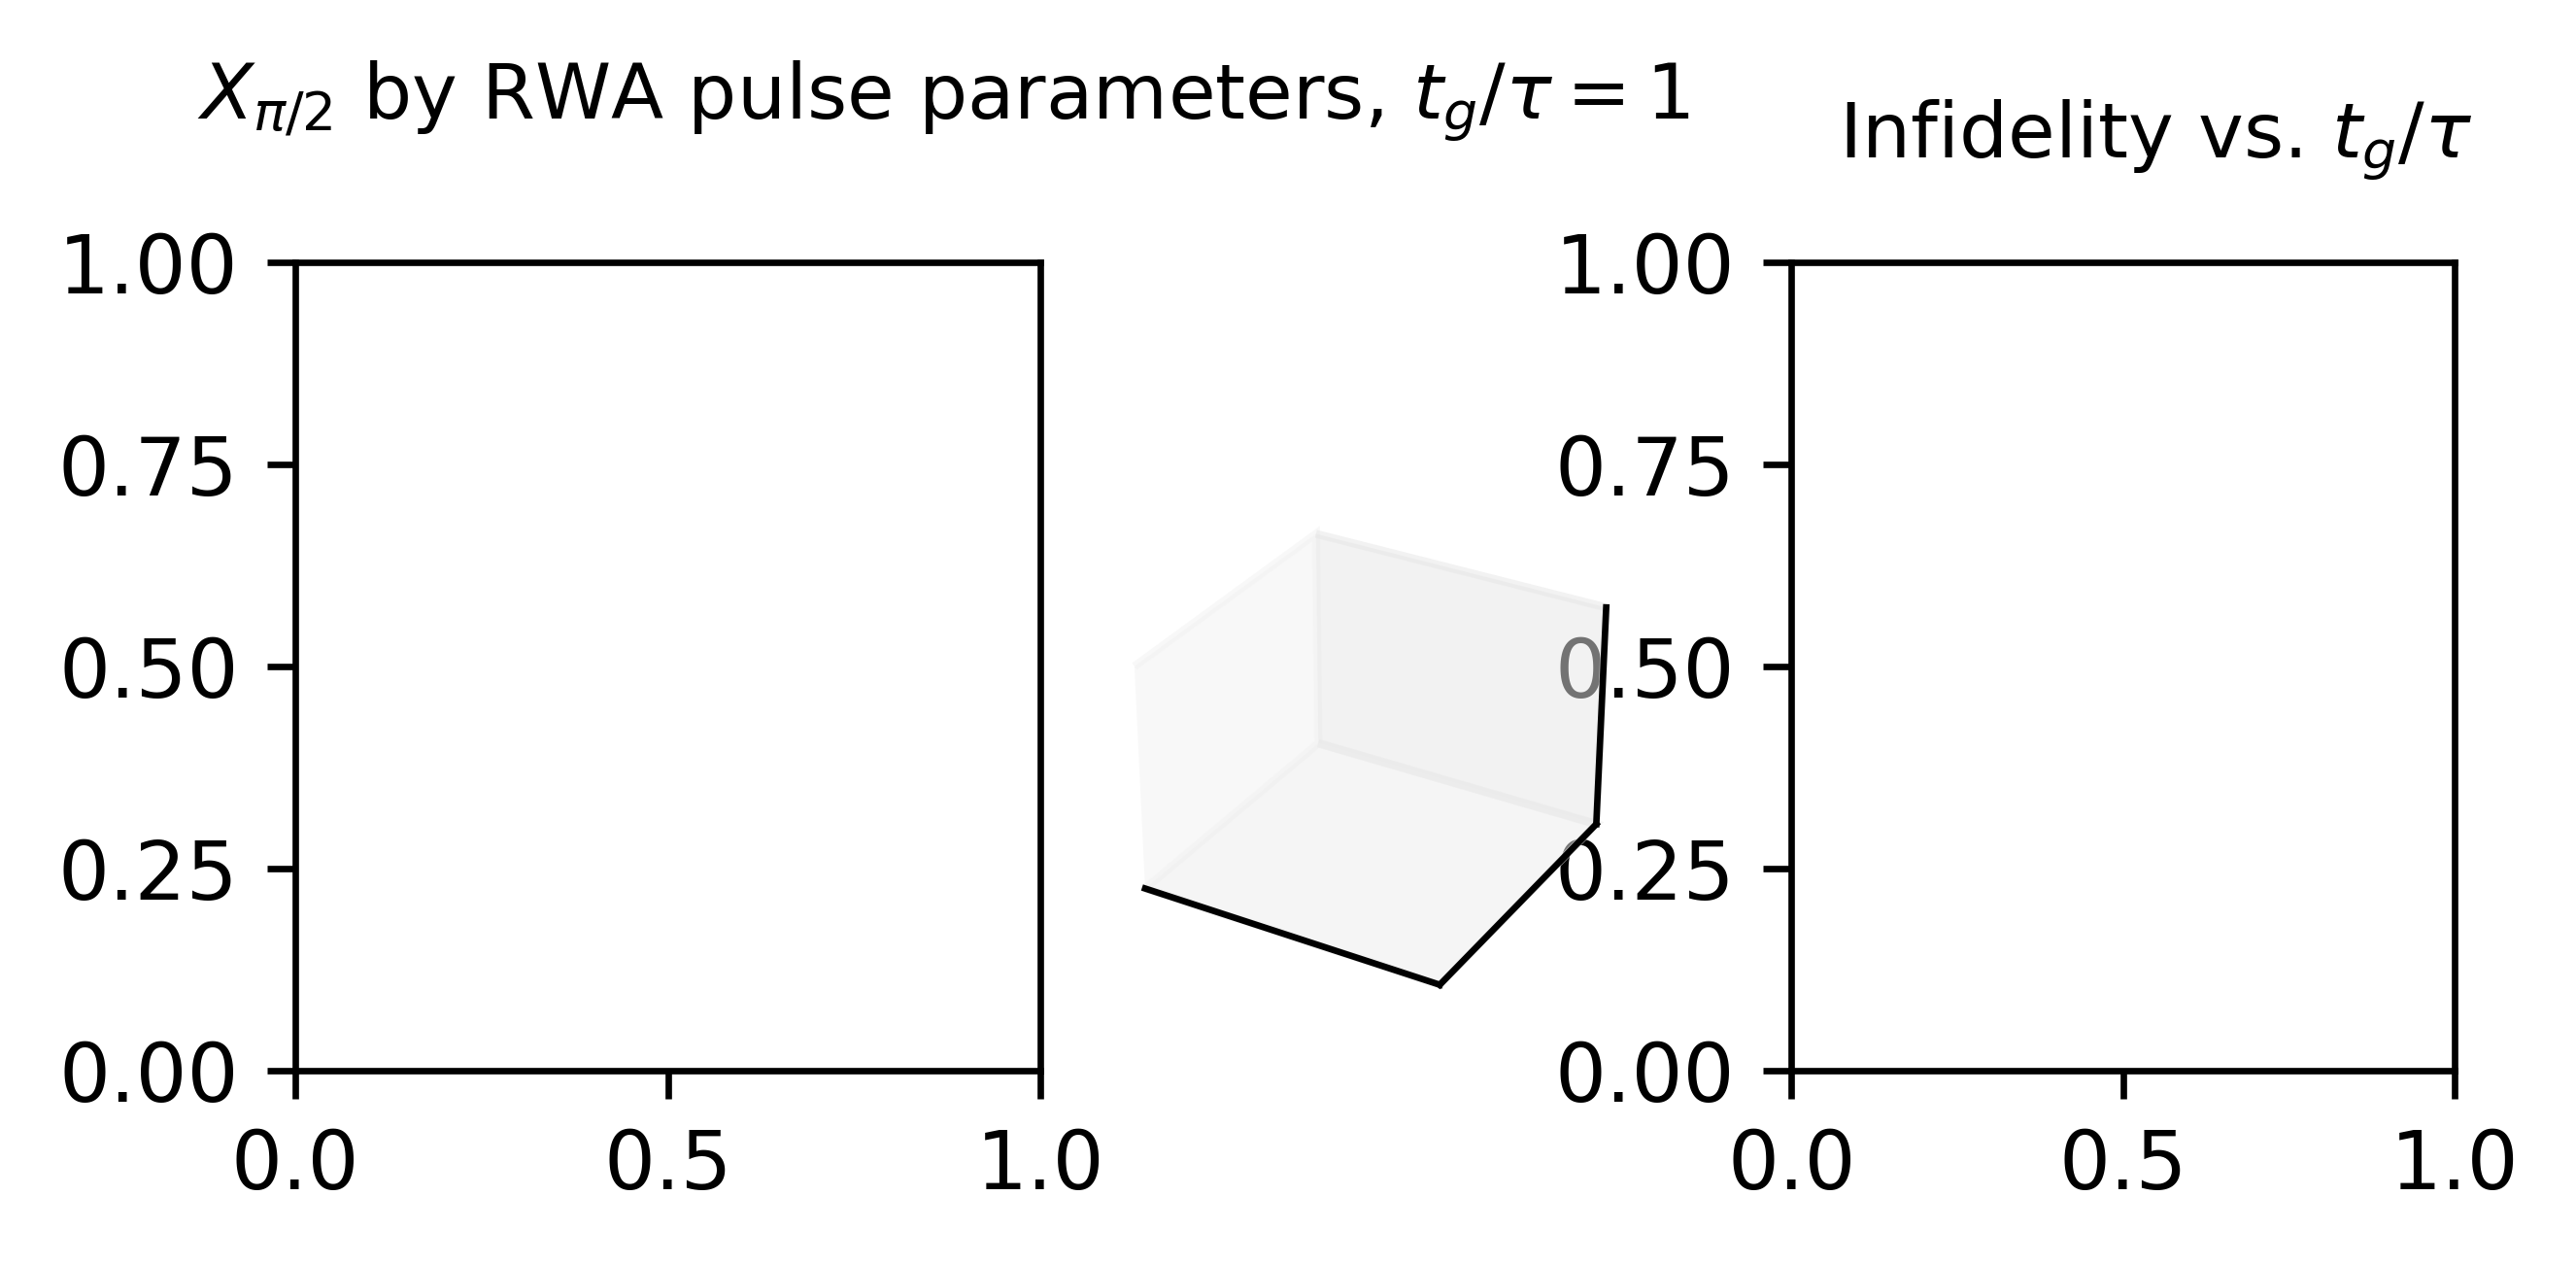

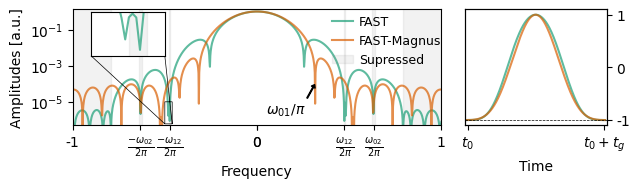

In [4]:
#DRAG spectra plot
%load_ext autoreload
%autoreload
import matplotlib.pyplot as plt
import numpy as np
import utils.gate_params as gp
import utils.eval_functions as ef
from utils.eval_functions import AdaptiveLearner
Lambda = 1.5
learner = AdaptiveLearner([], [None, 1, None, 1, 2, np.pi, (Lambda,Lambda+0.0001), np.inf, np.inf], framework="random",truncation=3)
learner = AdaptiveLearner([], [None, 1, None, 1, 1.99, np.pi, (Lambda,Lambda+0.0001), np.inf, np.inf], framework="random",truncation=3)
#learner = AdaptiveLearner([], [None, 1, None, 1, 1.1, np.pi, (Lambda,Lambda+0.0001), np.inf, np.inf], framework="random",truncation=3)
#learner = AdaptiveLearner([], [None, 1, None, 0.1, 0.2, np.pi, (Lambda,Lambda+0.0001), np.inf, np.inf], framework="random",truncation=3)
qubits_2_eval = learner.get_next_dp(N=1)
for i in range(len(qubits_2_eval)):
    qubits_2_eval[i]["Ec_IC"] = 0.4
    qubits_2_eval[i]["El_IC"] = 1
    qubits_2_eval[i]["Ej_IC"] = 1.3
gate = gp.get_gate_params("FAST_nooptim")
gate2 = gp.get_gate_params("FAST-MAGNUS")
#gate = gp.get_gate_params("FAST-DRAG")
#gate2 = gp.get_gate_params("FAST-MAGNUS-DRAG")
t_0 = 0.0
qubit, gate = ef.calib_gate((qubits_2_eval[0], gate))
t_g = qubit["t_g"]
_, gate2 = ef.calib_gate((qubits_2_eval[0], gate2))
coffs = gate.envelope_coffs
coffs2 = gate2.envelope_coffs
def envelope_func(t):
    if t < 0 or t >  t_g:
        return 0
    else:
        return sum([coffs[i] * (1-np.cos(2 * np.pi * (i+1) * (t-t_0) / t_g)) for i in range(len(coffs))])
def envelope_func2(t):
    if t < 0 or t >  t_g:
        return 0
    else:
        return sum([coffs2[i] * (1-np.cos(2 * np.pi * (i+1) * (t-t_0) / t_g)) for i in range(len(coffs2))])
#do a fourier transform of this envelope
def fourier_transform(f):
    X = np.linspace(0, t_g, 200)
    envelope = np.array([envelope_func(t) for t in X], dtype=np.float64)
    wave = np.exp(2j * np.pi * f * X)
    return np.trapz(envelope * wave, X)
def fourier_transform2(f):
    X = np.linspace(0, t_g, 400)
    envelope = np.array([envelope_func2(t) for t in X], dtype=np.float64)
    wave = np.exp(2j * np.pi * f * X)
    return np.trapz(envelope * wave, X)
axins = None
def plot_DRAG_spectra(frequencies, ax):
    global axins
    from tqdm import tqdm
    spectra = [fourier_transform(f) for f in tqdm(frequencies)]
    spectra2 = [fourier_transform2(f) for f in tqdm(frequencies)]
    spectra /= np.max(np.abs(spectra))
    spectra2 /= np.max(np.abs(spectra2))
    ax.plot(frequencies, np.abs(spectra), label='FAST', color='#1b9e77', alpha=0.7)
    ax.plot(frequencies, np.abs(spectra2), label='FAST-Magnus', color='#d95f02', alpha=0.7)
    ax.set_xlabel('Frequency')
    ax.set_ylabel('Amplitudes [a.u.]')
    #make a zoomed-in frame
    x1, x2 = -0.5, -0.46
    y1, y2 = 6e-7, 1e-5

    axins = ax.inset_axes(
        [0.05, 0.6, 0.20, 0.38],
        xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[],xticks=[], yticks=[],
    )
    #make ackground transparent
    #axins.patch.set_alpha(0.0)
    axins.plot(frequencies, np.abs(spectra), color='#1b9e77', alpha=0.7)
    axins.plot(frequencies, np.abs(spectra2), color='#d95f02', alpha=0.7)
    axins.set_yscale('log')
    ax.indicate_inset_zoom(axins, edgecolor="black", lw=0.5, alpha=1, ls='-')
    axins.set_yticks([])
    axins.set_yticklabels([])
    axins.set_xticks([])
    axins.set_xticklabels([])
    axins.set_yticks([], minor=True)
    axins.set_xticks([], minor=True)
    #ax.set_title('FAST spectrum')
    #ax.grid(True)
    return spectra, spectra2
    
#forbidden 
forbidden = gate.forbidden_intervals
import sympy as sp
omega_01 = qubit["omega_01_actual"]
omega_12 = qubit["omega_12_actual"]
#fig, ax = plt.subplots(figsize=(5, 2.5))
fig, axs = plt.subplots(1,2, figsize=(6.5, 2), width_ratios=[2.6, 1])
ax = axs[0]
ax2 = axs[1]



r = 1
frequencies = np.linspace(-r, r, 1000)  # Frequency range for the spectrum
s1,s2 = plot_DRAG_spectra(frequencies, ax)
xticks = [0]
xlabels = [r'$0$']

for i in range(len(forbidden)):
    forbidden[i] = list(forbidden[i])
    for j in range(len(forbidden[i])):
        if isinstance(forbidden[i][j], sp.Basic):
            forbidden[i][j] = forbidden[i][j].subs(sp.symbols('omega_{01}'), omega_01)
            forbidden[i][j] = forbidden[i][j].subs(sp.symbols('omega_{12}'), omega_12)
            forbidden[i][j] = float(forbidden[i][j])
        if np.isinf(np.abs(forbidden[i][j])):
            forbidden[i][j] = 1000000
    #plot these as grey shaded regions
    #ax.axvspan(forbidden[i][0], forbidden[i][1], color='grey', alpha=0.1, label='Forbidden Region' if i == 0 else "")
    x1 = forbidden[i][0]
    x2 = forbidden[i][1]
    y1= 1e-8
    y2 = 1000
    ax.fill_betweenx([y1, y2], x1, x2, color='grey', alpha=0.1, label='Supressed' if i == 0 else "")
    ax.fill_betweenx([y1, y2], -x1, -x2, color='grey', alpha=0.1)
    #axins.fill_betweenx([y1, y2], x1, x2, color='grey', alpha=0.1)
    axins.fill_betweenx([y1, y2], -x1, -x2, color='grey', alpha=0.1)
    avg = (x1 + x2) / 2
    if avg < 100000:
        xticks.append(avg)
        xticks.append(-avg)
    else:
        pass
        #xticks.append(x1)
        #xticks.append(-x1)

xlabels += [r'$\frac{\omega_{{02}}}{2\pi}$', r'$\frac{-\omega_{{02}}}{2\pi}$']

xlabels += [r'$\frac{\omega_{{12}}}{2\pi}$', r'$\frac{-\omega_{{12}}}{2\pi}$']
#xlabels += [r'$\frac{\omega_{{01}}+\omega_{{02}}}{2\pi}$', r'$-\frac{\omega_{{01}}+\omega_{{02}}}{2\pi}$']

#ax1 = ax.twiny()
#ax1.set_xticks(xticks)
#ax1.set_xticklabels(xlabels)
#ax1.set_xlim(-1.1, 1.1)
lgnd = ax.legend(fontsize=9, loc='upper right', frameon=False, bbox_to_anchor=(1.03,1.05))
lgnd.legend_handles[2]._width = 15
lgnd.legend_handles[2]._x0 = 6
lgnd.legend_handles[1]._xorig[2] = 21
lgnd.legend_handles[1]._xorig[0] = 6
lgnd.legend_handles[0]._xorig[2] = 21
lgnd.legend_handles[0]._xorig[0] = 6
ax.set_yscale('log')
ax.set_ylim(5e-7, 1.3)
ax.set_xlim(-r,r)

#plot the time domain of the envelope
X = np.linspace(-0.1, t_g+0.1, 1000)
envelope = np.array([envelope_func(t) for t in X], dtype=np.float64)
envelope /= np.max(np.abs(envelope))  # Normalize the envelope
ax2.plot(X, envelope, label='Envelope', color='#1b9e77', alpha=0.7)
envelope2 = np.array([envelope_func2(t) for t in X], dtype=np.float64)
envelope2 /= np.max(np.abs(envelope2))  # Normalize the envelope
ax2.plot(X, envelope2, label='Envelope (Dyson)', color='#d95f02', alpha=0.7)
ax2.set_xlabel('Time')
#ax2.set_ylabel('Amplitude')
#ax2.set_title('Envelope in time domain')
ax2.set_xlim(-0.2, t_g+0.2)
#ax2.axhline(0, color='black', lw=0.5, ls='--')
#ax2.axvline(0, color='black', lw=0.5, ls='--')
ax2.set_xticks([0, t_g])
ax2.set_xticklabels([rf'$t_0$', rf'$t_0 + t_g$'])
ax2.set_yticks([])
ax2.set_yticklabels([])
#ax2.legend(fontsize=9, loc='upper right', frameon=False, bbox_to_anchor=(1.03,1.05))
ax2.axhline(0, color='black', lw=0.5, ls='--')
#ax2.set_aspect('equal', adjustable='box')  
ax3 = ax2.twinx()
ax3.set_yticks([-1, 0, 1])
ax3.set_yticklabels(['-1', '0', '1'])
ax3.set_ylim(-1.1, 1.1)
#ax3.set_ylabel('Normalized Amplitude')

annot_x = omega_01/np.pi
indx_cord = np.argmin(np.abs(frequencies - annot_x))
annot_y = 1e-4
ax.annotate(f'$\omega_{{01}}/\pi$',
    xy=(annot_x, annot_y), 
    xytext=(omega_01/np.pi*2, 0.1), 
    textcoords='axes fraction',
    arrowprops=dict(facecolor='black', shrink=0.05, width=0.5, headwidth=3, headlength=2),
    horizontalalignment='right')

xticks += [-1,0, 1]
xlabels += ['-1', '0', '1']
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)



#raise UserWarning("Make the markings for the supressed regions of the spectra")
plt.tight_layout()
plt.savefig('FAST_spectrum.pdf')
plt.show()